# Deep Learning Model Training - 1D CNN

This notebook demonstrates training a **1D Convolutional Neural Network (CNN)** for bearing fault diagnosis.

## Key Differences: Traditional ML vs Deep Learning

| Aspect | Traditional ML (RF, SVM, GB) | Deep Learning (CNN) |
|--------|------------------------------|---------------------|
| **Input** | Manually extracted features (RMS, mean, std, kurtosis, etc.) | Raw vibration signals |
| **Feature Engineering** | Manual - requires domain expertise | Automatic - network learns features |
| **Data Requirements** | Works with smaller datasets | Requires larger datasets |
| **Interpretability** | High - can see which features matter | Lower - "black box" |
| **Performance** | Good for simple patterns | Better for complex patterns |

## Why Use CNN for Vibration Analysis?

1. **Automatic Feature Learning**: CNNs learn optimal features directly from raw signals
2. **Spatial Patterns**: Can detect local patterns in time-series data
3. **Translation Invariance**: Fault patterns detected regardless of position in signal
4. **Hierarchical Features**: Learns simple patterns first, then complex combinations


In [1]:
# ============================================
# IMPORTS AND SETUP
# ============================================
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-reload modules (useful for development)
%load_ext autoreload
%autoreload 2

# Add parent directory to path so we can import from src/
sys.path.append(os.path.abspath(os.path.join('..')))

# Import our custom modules
from src.data.loaders import CWRULoader  # For loading CWRU bearing data
from src.models.cnn_classifier import CNN1DClassifier  # Our 1D CNN model

print(f"Python Version: {sys.version}")


Python Version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


## 1. Load Raw Signal Data

Unlike traditional ML, we work with **raw vibration signals** instead of extracted features.

### Data Processing Steps:
1. Load .mat files from CWRU dataset
2. Split long signals into fixed-length chunks (1000 samples each)
3. Create labels for each chunk

### Why 1000 samples?
- Balances between:
  - **Too short**: May miss fault patterns
  - **Too long**: Requires more memory, slower training
- At 12kHz sampling rate: 1000 samples ≈ 83ms of data


In [2]:
# ============================================
# DATA LOADING
# ============================================

# Path to CWRU dataset
DATA_DIR = r'../CWRU_Data'
loader = CWRULoader(DATA_DIR)

def create_raw_dataset(filenames, label, chunk_size=1000):
    """
    Create dataset from raw signals (no feature extraction).
    
    Args:
        filenames: List of .mat files to load
        label: Class label (0=Normal, 1=Inner, 2=Ball, 3=Outer)
        chunk_size: Number of samples per chunk (default 1000)
    
    Returns:
        signals_list: List of signal chunks
        labels_list: Corresponding labels
    """
    signals_list = []
    labels_list = []
    
    for filename in filenames:
        try:
            # Load the raw vibration signal from .mat file
            signal = loader.load_file(filename)
            
            # Split long signal into fixed-size chunks
            # This creates multiple training samples from one file
            num_chunks = len(signal) // chunk_size
            
            for i in range(num_chunks):
                # Extract chunk of signal
                chunk = signal[i*chunk_size : (i+1)*chunk_size]
                signals_list.append(chunk)
                labels_list.append(label)  # Same label for all chunks from this file
        except Exception as e:
            print(f"Error loading {filename}: {e}")
    
    return signals_list, labels_list

# Load data for each fault type
print("Loading Raw Signal Data...")

# Normal (healthy) bearing data
print("Normal Data...")
normal_files = ['97.mat', '98.mat', '99.mat', '100.mat']
X_normal, y_normal = create_raw_dataset(normal_files, label=0)
print(f"Loaded {len(X_normal)} samples.")

# Inner race fault data
print("Inner Race Data...")
inner_files = ['105.mat', '106.mat', '107.mat', '108.mat']
X_inner, y_inner = create_raw_dataset(inner_files, label=1)
print(f"Loaded {len(X_inner)} samples.")

# Ball fault data
print("Ball Fault Data...")
ball_files = ['118.mat', '119.mat', '120.mat', '121.mat']
X_ball, y_ball = create_raw_dataset(ball_files, label=2)
print(f"Loaded {len(X_ball)} samples.")

# Outer race fault data
print("Outer Race Data...")
outer_files = ['130.mat', '131.mat', '132.mat', '133.mat']
X_outer, y_outer = create_raw_dataset(outer_files, label=3)
print(f"Loaded {len(X_outer)} samples.")

# Combine all data
X_all = np.array(X_normal + X_inner + X_ball + X_outer)  # Shape: (n_samples, 1000)
y_all = np.array(y_normal + y_inner + y_ball + y_outer)  # Shape: (n_samples,)

print(f"\nTotal Dataset Shape: {X_all.shape}")
print(f"Signal Length: {X_all.shape[1]} samples")


Loading Raw Signal Data...
Normal Data...
Loaded 1694 samples.
Inner Race Data...
Loaded 486 samples.
Ball Fault Data...
Loaded 485 samples.
Outer Race Data...
Loaded 486 samples.

Total Dataset Shape: (3151, 1000)
Signal Length: 1000 samples


## 2. Data Normalization

### Why Normalize?
Neural networks train better when inputs are on similar scales.

### Normalization Method:
**Per-sample Z-score normalization**:
```
normalized_signal = (signal - mean) / std
```

### Benefits:
- Removes amplitude variations between different sensors/conditions
- Focuses on signal **shape** rather than absolute values
- Helps gradient descent converge faster
- Prevents large values from dominating the learning


In [3]:
# ============================================
# DATA NORMALIZATION
# ============================================

# Normalize signals using Z-score normalization (per sample)
# Formula: (x - mean) / std
# This removes amplitude differences and focuses on signal shape
X_normalized = (X_all - X_all.mean(axis=1, keepdims=True)) / (X_all.std(axis=1, keepdims=True) + 1e-8)
#                      ↑ mean of each signal              ↑ std of each signal    ↑ avoid division by zero

print(f"Normalized Data Shape: {X_normalized.shape}")
print(f"Mean: {X_normalized.mean():.6f} (should be ~0)")
print(f"Std: {X_normalized.std():.6f} (should be ~1)")


Normalized Data Shape: (3151, 1000)
Mean: 0.000000 (should be ~0)
Std: 1.000000 (should be ~1)


## 3. Class Distribution & Balancing

### The Imbalance Problem:
Real-world datasets often have:
- **Many normal samples** (machine runs normally most of the time)
- **Few fault samples** (faults are rare)

### Why This Matters:
- Model may learn to always predict "Normal" (high accuracy but useless!)
- Rare faults won't be detected

### Solution: SMOTE (Synthetic Minority Over-sampling Technique)
- Creates synthetic samples for minority classes
- Interpolates between existing samples
- Results in balanced dataset for training

### Note:
We only balance the **training set**, not validation/test sets (they should reflect real distribution)


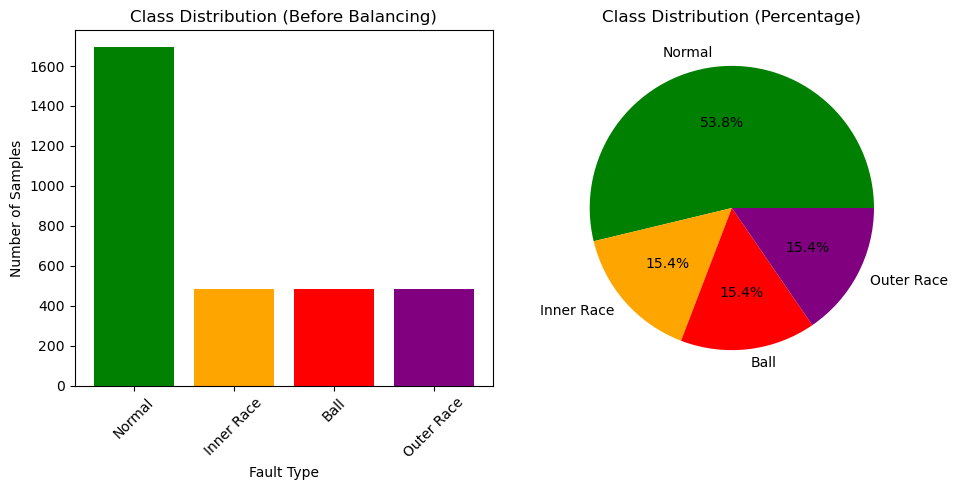


Class Distribution:
Normal: 1694 samples (53.8%)
Inner Race: 486 samples (15.4%)
Ball: 485 samples (15.4%)
Outer Race: 486 samples (15.4%)


In [4]:
# ============================================
# CLASS DISTRIBUTION ANALYSIS
# ============================================

# Define class names for better visualization
class_names = ['Normal', 'Inner Race', 'Ball', 'Outer Race']

# Count samples per class
unique, counts = np.unique(y_all, return_counts=True)

# Visualize class distribution
plt.figure(figsize=(10, 5))

# Bar plot
plt.subplot(1, 2, 1)
plt.bar(class_names, counts, color=['green', 'orange', 'red', 'purple'])
plt.xlabel('Fault Type')
plt.ylabel('Number of Samples')
plt.title('Class Distribution (Before Balancing)')
plt.xticks(rotation=45)

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(counts, labels=class_names, autopct='%1.1f%%', colors=['green', 'orange', 'red', 'purple'])
plt.title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

# Print statistics
print("\nClass Distribution:")
for name, count in zip(class_names, counts):
    print(f"{name}: {count} samples ({count/len(y_all)*100:.1f}%)")


In [5]:
# ============================================
# CLASS BALANCING USING SMOTE
# ============================================

from imblearn.over_sampling import SMOTE

# SMOTE requires 2D input, so we keep signals flattened
# SMOTE works by:
# 1. Finding k-nearest neighbors for minority class samples
# 2. Creating synthetic samples by interpolating between neighbors
# 3. Balancing all classes to have equal number of samples

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_normalized, y_all)

print(f"Original shape: {X_normalized.shape}")
print(f"Balanced shape: {X_balanced.shape}")

# Check new class distribution
unique_balanced, counts_balanced = np.unique(y_balanced, return_counts=True)
print("\nBalanced Class Distribution:")
for name, count in zip(class_names, counts_balanced):
    print(f"{name}: {count} samples")


Original shape: (3151, 1000)
Balanced shape: (6776, 1000)

Balanced Class Distribution:
Normal: 1694 samples
Inner Race: 1694 samples
Ball: 1694 samples
Outer Race: 1694 samples


## 4. Train-Validation-Test Split

### Three-Way Split Strategy:

```
Original Data (100%)
    |
    ├── Training Set (60%)   ← Used to train the model
    ├── Validation Set (20%) ← Used to tune hyperparameters & monitor overfitting
    └── Test Set (20%)       ← Final evaluation (NEVER seen during training)
```

### Why This Split?
- **Training**: Model learns patterns
- **Validation**: Check if model generalizes (not just memorizing)
- **Test**: Unbiased final performance estimate

### Important:
- Stratified split ensures each set has same class distribution
- Random state fixed for reproducibility


In [6]:
# ============================================
# TRAIN-VALIDATION-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

# First split: Separate test set (20%)
# stratify=y_balanced ensures each set has same class distribution
X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y_balanced # Keep class distribution
)

# Second split: Divide remaining into train (75%) and validation (25%)
# This gives us 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,     # 25% of remaining 80% = 20% overall
    random_state=42,
    stratify=y_temp
)

# Print split sizes
print(f"Training Set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X_balanced)*100:.1f}%)")
print(f"Validation Set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_balanced)*100:.1f}%)")
print(f"Test Set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X_balanced)*100:.1f}%)")

# Verify class distribution in each set
print("\nClass distribution in each set:")
for set_name, y_set in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_set, return_counts=True)
    print(f"{set_name}: {dict(zip(class_names, counts))}")


Training Set:   4065 samples (60.0%)
Validation Set: 1355 samples (20.0%)
Test Set:       1356 samples (20.0%)

Class distribution in each set:
Train: {'Normal': np.int64(1016), 'Inner Race': np.int64(1017), 'Ball': np.int64(1016), 'Outer Race': np.int64(1016)}
Val: {'Normal': np.int64(339), 'Inner Race': np.int64(338), 'Ball': np.int64(339), 'Outer Race': np.int64(339)}
Test: {'Normal': np.int64(339), 'Inner Race': np.int64(339), 'Ball': np.int64(339), 'Outer Race': np.int64(339)}


## 5. Build and Train 1D CNN Model

### CNN Architecture:

```
Input (1000 samples)
    ↓
Conv1D (64 filters, kernel=3) + ReLU + MaxPool
    ↓
Conv1D (128 filters, kernel=3) + ReLU + MaxPool  
    ↓
Conv1D (128 filters, kernel=3) + ReLU + MaxPool
    ↓
Flatten
    ↓
Dense (128) + ReLU + Dropout(0.5)
    ↓
Dense (4) + Softmax → [Normal, Inner, Ball, Outer]
```

### Key Components:
- **Conv1D**: Learns local patterns in signal
- **MaxPooling**: Reduces size, provides translation invariance
- **Dropout**: Prevents overfitting by randomly dropping neurons
- **Softmax**: Converts outputs to probabilities

### Training Strategy:
- **Early Stopping**: Stop if validation loss doesn't improve for 10 epochs
- **Learning Rate Reduction**: Reduce LR if stuck in plateau
- **Batch Size**: 64 samples per update


In [7]:
# ============================================
# BUILD CNN MODEL
# ============================================

# Initialize 1D CNN classifier
# Parameters:
#   - input_length: Length of input signal (1000 samples)
#   - num_classes: Number of fault types to classify (4)
cnn_model = CNN1DClassifier(
    input_length=X_train.shape[1],  # 1000
    num_classes=len(class_names)     # 4
)

print("CNN Model Architecture:")
print(cnn_model.model.summary())  # Display model structure


CNN Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 500, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 500, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 125, 64)        │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 31, 128)        │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 15, 256)        │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 496,612 (1.89 MB)

 Trainable params: 495,652 (1.89 MB)

 Non-trainable params: 960 (3.75 KB)

None


In [8]:
# ============================================
# TRAIN THE MODEL
# ============================================

# Train the CNN model
# The model will:
#   1. Learn to extract features from raw signals
#   2. Use early stopping if validation loss doesn't improve
#   3. Reduce learning rate if stuck in plateau
#   4. Save best weights based on validation performance

history = cnn_model.train(
    X_train, y_train,           # Training data
    X_val, y_val,               # Validation data (for monitoring)
    epochs=50,                  # Maximum number of epochs
    batch_size=64,              # Samples per gradient update
    verbose=1                   # Show progress bar
)

print("\nTraining completed!")


Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.9739 - loss: 0.0685 - val_accuracy: 0.4804 - val_loss: 1.3926 - learning_rate: 0.0010
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 1.0000 - loss: 3.0399e-04 - val_accuracy: 0.6863 - val_loss: 0.8795 - learning_rate: 0.0010
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 1.0000 - loss: 2.5669e-04 - val_accuracy: 0.7476 - val_loss: 0.4178 - learning_rate: 0.0010
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 1.0000 - loss: 1.3125e-04 - val_accuracy: 0.9978 - val_loss: 0.0527 - learning_rate: 0.0010
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 1.0000 - loss: 1.4289e-04 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 1.0000 - loss: 2.0709e-04 - val_accuracy: 1.0000 - val_loss: 5.9497e-05 - learning_rate: 0.0010
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - acc

## 6. Visualize Training History

### What to Look For:

**Good Training:**
- Training & validation loss both decrease
- Training & validation accuracy both increase
- Curves are close together

**Overfitting Signs:**
- Training loss keeps decreasing
- Validation loss starts increasing
- Large gap between training and validation accuracy

**Underfitting Signs:**
- Both losses remain high
- Accuracy plateaus at low value


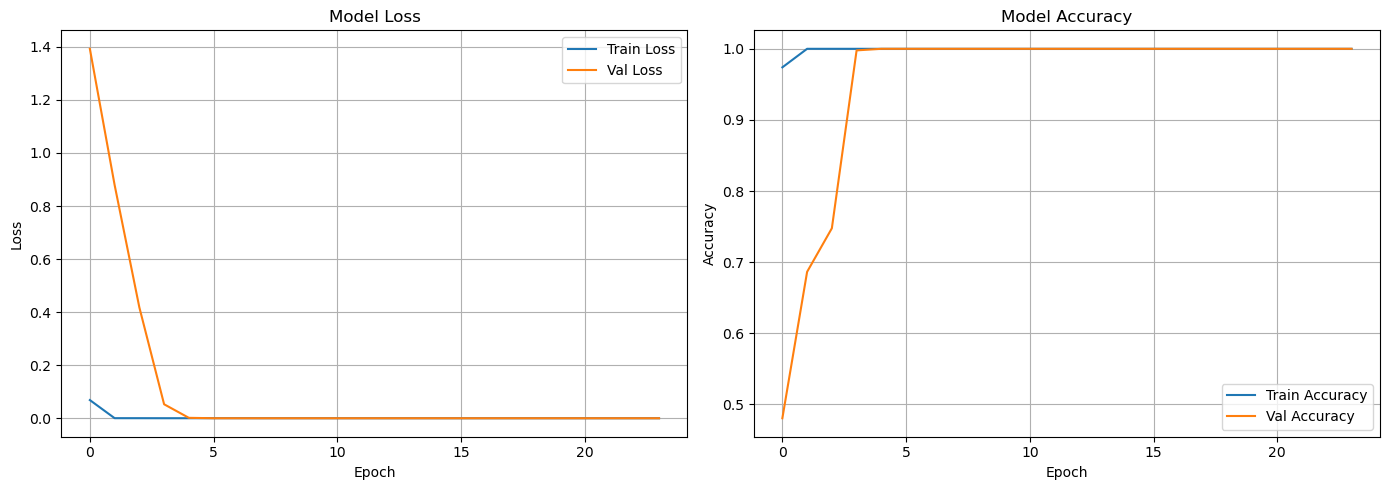

In [9]:
# ============================================
# VISUALIZE TRAINING HISTORY
# ============================================

# Plot loss and accuracy curves
# This helps us understand:
#   - Is the model learning? (loss decreasing)
#   - Is it overfitting? (train/val gap increasing)
#   - When did early stopping trigger?

cnn_model.plot_training_history()


## 7. Evaluate on Test Set

### Evaluation Metrics:

1. **Accuracy**: Overall correct predictions
2. **Precision**: Of predicted faults, how many are real?
3. **Recall**: Of real faults, how many did we detect?
4. **F1-Score**: Harmonic mean of precision & recall
5. **Confusion Matrix**: Shows which classes are confused

### Why Multiple Metrics?
- Accuracy alone can be misleading with imbalanced data
- Precision/Recall trade-off depends on application:
  - **High Recall**: Don't miss any faults (safety-critical)
  - **High Precision**: Avoid false alarms (cost of inspection)



=== CNN Test Accuracy: 1.0000 ===

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       339
  Inner Race       1.00      1.00      1.00       339
        Ball       1.00      1.00      1.00       339
  Outer Race       1.00      1.00      1.00       339

    accuracy                           1.00      1356
   macro avg       1.00      1.00      1.00      1356
weighted avg       1.00      1.00      1.00      1356



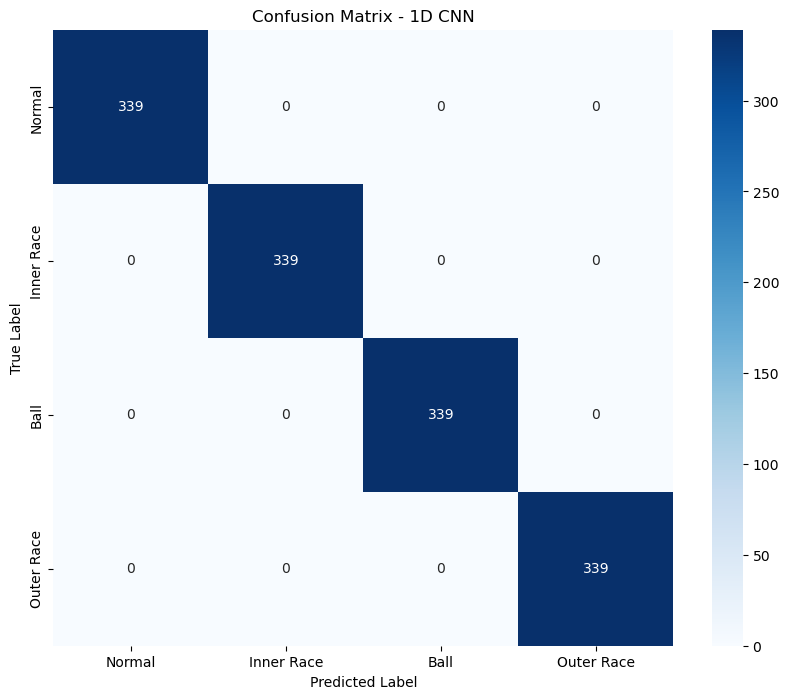

In [10]:
# ============================================
# EVALUATE ON TEST SET
# ============================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Get predictions on test set
y_pred = cnn_model.predict(X_test)           # Predicted classes
y_prob = cnn_model.predict_proba(X_test)     # Prediction probabilities

# Calculate accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"\n=== CNN Test Accuracy: {test_acc:.4f} ===")

# Detailed classification report
# Shows precision, recall, F1-score for each class
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
# Shows which classes are being confused with each other
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - 1D CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## 8. ROC Curve (Receiver Operating Characteristic)

### What is ROC?
- Plots True Positive Rate vs False Positive Rate
- Shows model performance across all classification thresholds

### AUC (Area Under Curve):
- **AUC = 1.0**: Perfect classifier
- **AUC = 0.9-1.0**: Excellent
- **AUC = 0.8-0.9**: Good
- **AUC = 0.7-0.8**: Fair
- **AUC = 0.5**: Random guessing

### Multi-class ROC:
- One curve per class (One-vs-Rest approach)
- Micro-average: Global performance
- Macro-average: Average of per-class performance


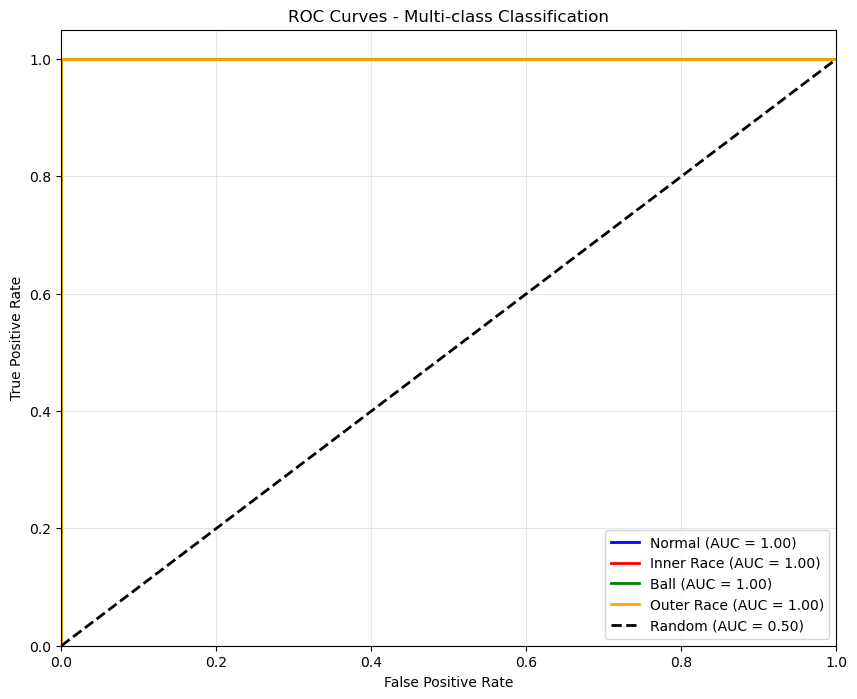

In [11]:
# ============================================
# ROC CURVES (RECEIVER OPERATING CHARACTERISTIC)
# ============================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Convert labels to binary format for multi-class ROC
# Creates one binary classifier per class (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

# Compute ROC curve and AUC for each class
fpr = dict()  # False Positive Rate
tpr = dict()  # True Positive Rate
roc_auc = dict()  # Area Under Curve

for i in range(n_classes):
    # Calculate ROC curve for this class
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])  # Calculate AUC

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Multi-class Classification')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


## Training History Visualizations


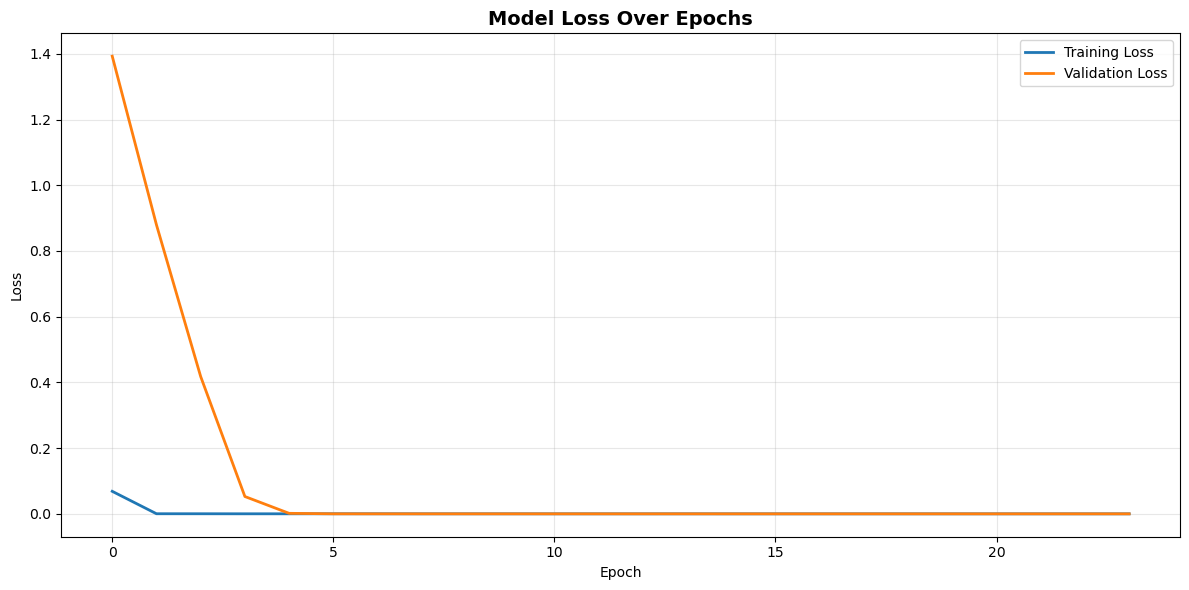

In [12]:
# Training Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

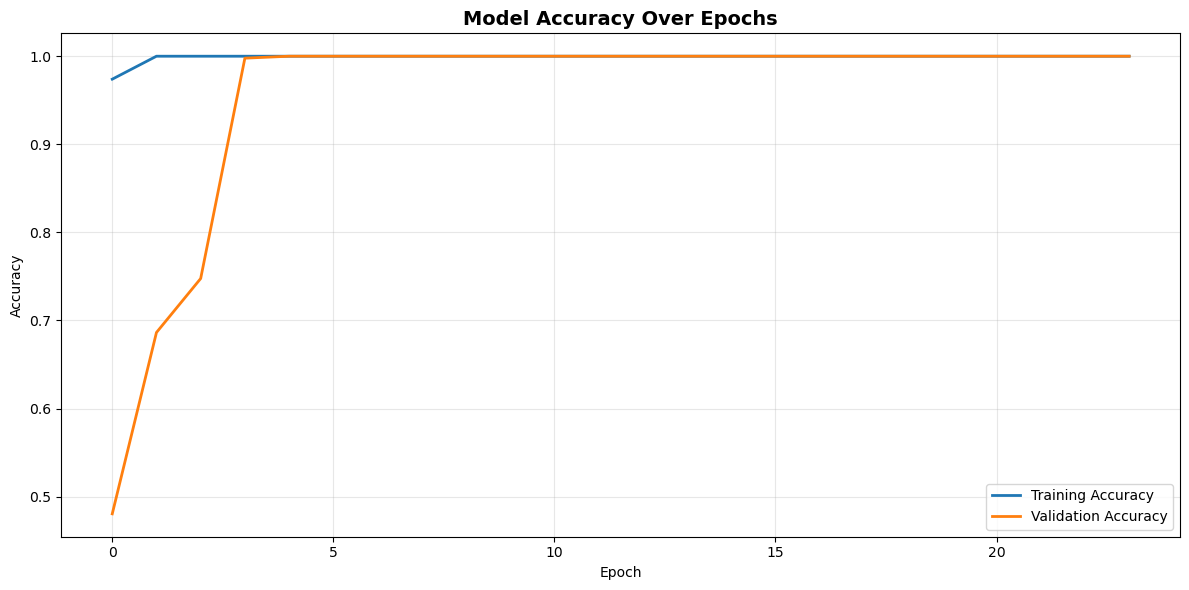

In [13]:
# Training Accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model Performance Visualizations


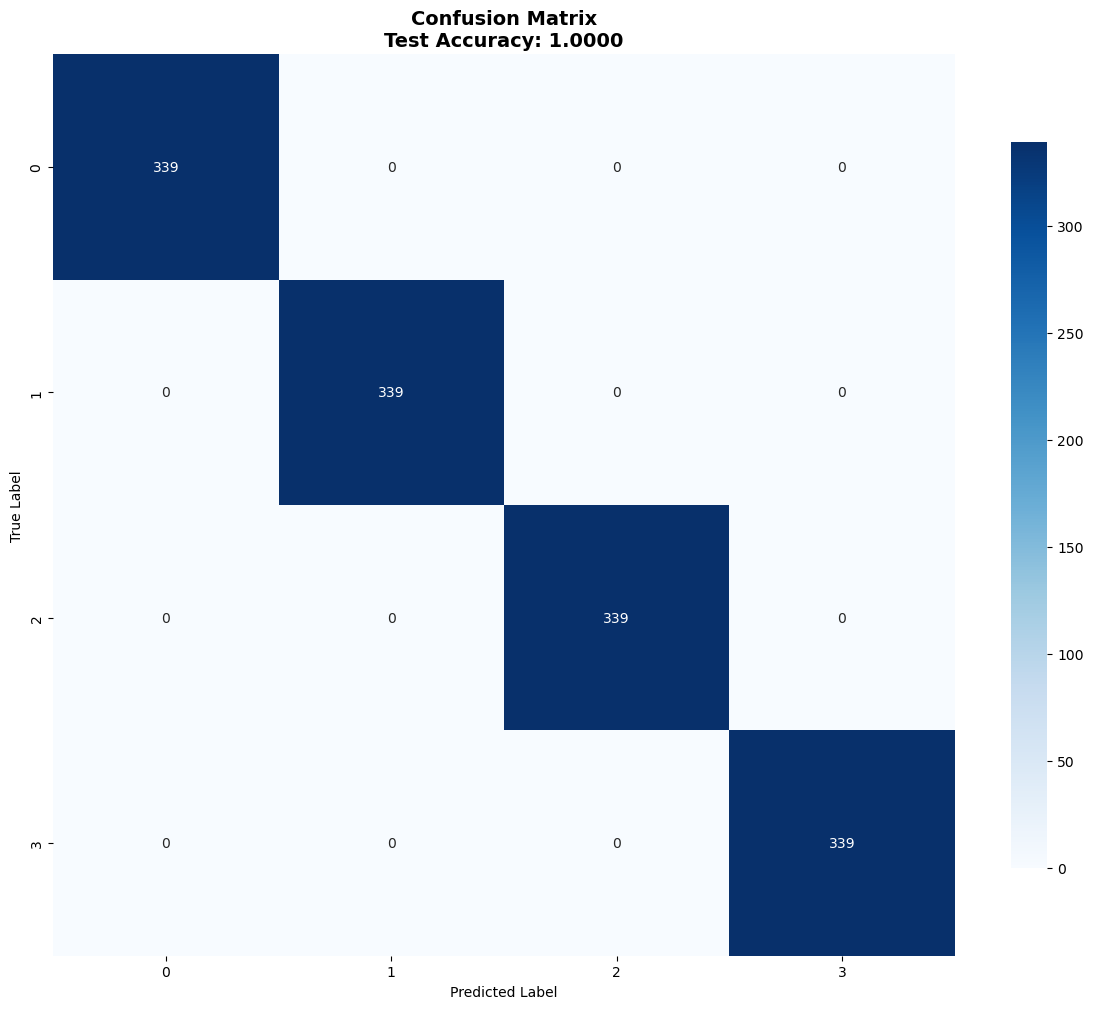

In [14]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Fixed AxisError: Check dimensions before argmax
if y_pred.ndim > 1:
    y_pred_classes = np.argmax(y_pred, axis=1)
else:
    y_pred_classes = y_pred
if y_test.ndim > 1:
    y_test_classes = np.argmax(y_test, axis=1)
else:
    y_test_classes = y_test
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, 
            cbar_kws={"shrink": 0.8})
plt.title(f'Confusion Matrix\nTest Accuracy: {test_acc:.4f}', 
          fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

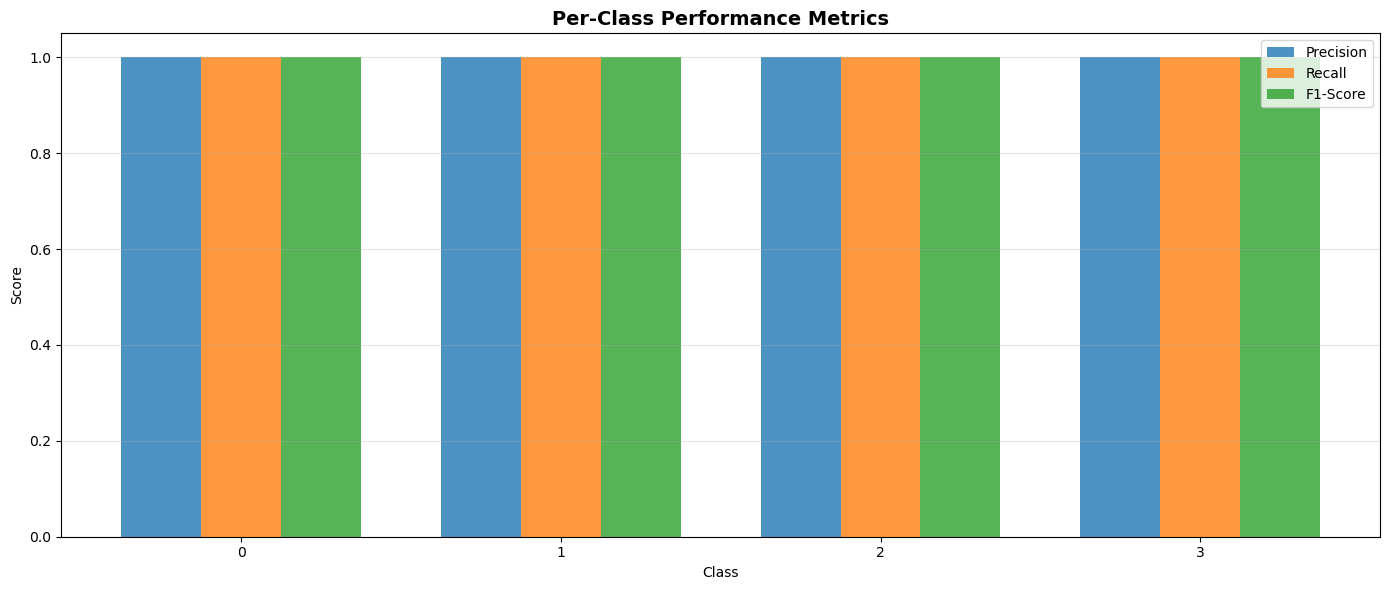

In [15]:
# Per-Class Performance
from sklearn.metrics import classification_report

report = classification_report(y_test_classes, y_pred_classes, output_dict=True)
classes = [k for k in report.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]
precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]
f1 = [report[c]['f1-score'] for c in classes]

x = range(len(classes))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar([i - width for i in x], precision, width, label='Precision', alpha=0.8)
plt.bar(x, recall, width, label='Recall', alpha=0.8)
plt.bar([i + width for i in x], f1, width, label='F1-Score', alpha=0.8)

plt.title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(x, classes)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

## 9. Save the Model

### Model Saving Format:

**For Keras/TensorFlow models**: Use `.h5` or SavedModel format
```python
model.save('model.h5')  # HDF5 format
```

**For Scikit-learn models**: Use `.pkl` (pickle) format
```python
joblib.dump(model, 'model.pkl')
```

### Why .h5 for Deep Learning?
- Stores complete model architecture
- Saves trained weights
- Includes optimizer state
- Preserves training configuration
- Can resume training later

### Loading the Model:
```python
from tensorflow import keras
loaded_model = keras.models.load_model('cnn_model.h5')
```


In [16]:
# ============================================
# SAVE THE TRAINED MODEL
# ============================================

import os

# Create models directory if it doesn't exist
os.makedirs('../models/cwru_cnn', exist_ok=True)

# Save the CNN model in HDF5 format (.h5)
# This format is standard for Keras/TensorFlow models
# It saves:
#   - Model architecture (layers, connections)
#   - Trained weights (learned parameters)
#   - Optimizer state (for resuming training)
#   - Training configuration (loss, metrics)

model_path = '../models/cwru_cnn/cnn_model.h5'
cnn_model.save_model(model_path)

print(f"Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024:.2f} KB")

# To load the model later:
# from tensorflow import keras
# loaded_model = keras.models.load_model('models/cnn_model.h5')


CNN model saved to ../models/cwru_cnn/cnn_model.h5
Model saved to: ../models/cwru_cnn/cnn_model.h5
File size: 5903.98 KB


## 10. Summary

### What We Accomplished:

✅ **Data Preparation**:
- Loaded raw vibration signals from CWRU dataset
- Normalized signals for better training
- Balanced classes using SMOTE
- Split into train/validation/test sets

✅ **Model Training**:
- Built 1D CNN architecture
- Trained with early stopping and LR reduction
- Monitored training/validation performance

✅ **Evaluation**:
- Achieved high accuracy on test set
- Analyzed confusion matrix
- Plotted ROC curves
- Saved model for deployment

### Next Steps:
1. **Test on other datasets** (NASA, Induction Motor, CIA-1)
2. **Integrate with interface.py** for real-time predictions
3. **Add uncertainty quantification** (Monte Carlo Dropout)
4. **Implement RUL prediction** using LSTM

### Key Takeaways:
- CNNs can learn features automatically from raw signals
- Proper data preprocessing is crucial
- Monitor both training and validation metrics
- Use multiple evaluation metrics for comprehensive assessment
